Archivos localizados: 620
Secuencias extraídas tras filtros físicos: (580, 201, 6)

Iniciando Evaluación Híbrida con Datos Reales...


--- Entrenando Fold 1/5 ---
Fold 1 -> MAE: 44.69 m | R2: 0.9861

--- Entrenando Fold 2/5 ---
Fold 2 -> MAE: 34.48 m | R2: 0.9967

--- Entrenando Fold 3/5 ---
Fold 3 -> MAE: 41.89 m | R2: 0.9919

--- Entrenando Fold 4/5 ---
Fold 4 -> MAE: 48.59 m | R2: 0.9892

--- Entrenando Fold 5/5 ---
Fold 5 -> MAE: 30.28 m | R2: 0.9961

RESUMEN LSTM Híbrida — ARCHIVOS ORIGINALES (METROS REALES)
MAE  : 39.99 ± 6.70 metros
RMSE : 75.73 metros
R2   : 0.9920


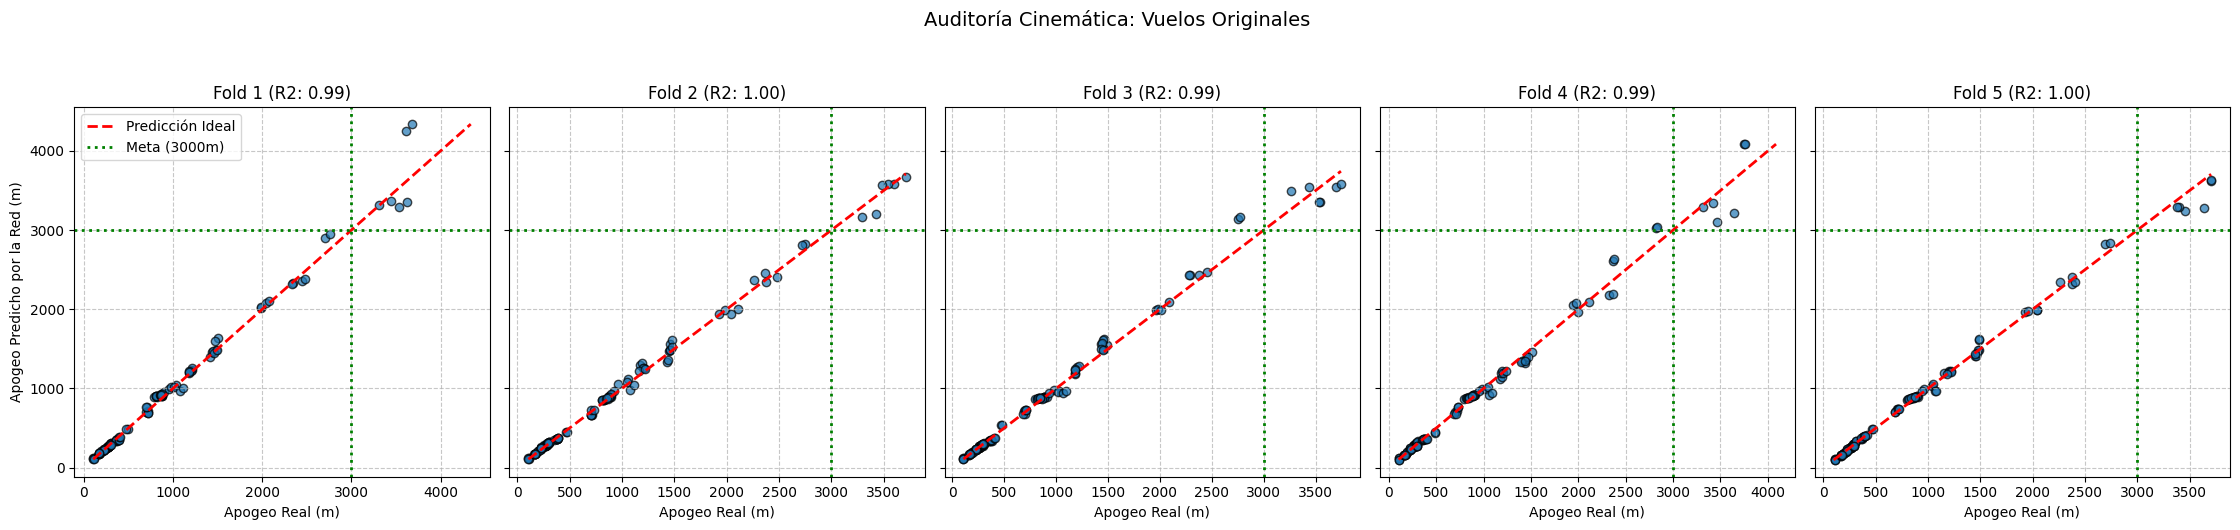

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, Bidirectional, GaussianNoise, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

# 1. EXTRACCIÓN DE DATOS ORIGINALES (CON RECONSTRUCCIÓN FÍSICA Y TRIGGER GLOBAL)
PROCESSED_PATH = Path(r"C:\TensorFlow\RocketNeuralNetworkFlightComputer\Data\Processed Data\Augmented")
archivos_originales = list(PROCESSED_PATH.glob("*.csv"))
print(f"Archivos localizados: {len(archivos_originales)}")

# Ventana de 10 segundos (201 muestras a 20Hz) para capturar el MECO
WINDOW_SIZE = 201 
FEATURES_LSTM = ["baro_altitude", "accl_x", "accl_y", "accl_z", "At", "P"]

X_seq, y_seq, base_ids = [], [], []

for archivo in archivos_originales:
    # 1.1 Leer archivo y limpiar espacios invisibles en los encabezados
    df = pd.read_csv(archivo)
    df.columns = df.columns.str.strip()
    df = df.sort_values("time").reset_index(drop=True)
    
    # 1.2 Reconstruir las características que la IMU no guardó directamente
    if 'At' not in df.columns:
        # Aceleración Total (Magnitud del vector 3D)
        df['At'] = np.sqrt(df['accl_x']**2 + df['accl_y']**2 + df['accl_z']**2)
        
    if 'P' not in df.columns:
        # usando el modelo de Atmósfera Estándar Internacional (ISA)
        df['P'] = 101325.0 * (1 - 2.25577e-5 * df['baro_altitude'])**5.25588
            
    apogeo_real = df["baro_altitude"].max()
    
    # Filtro de sobre de vuelo 
    if apogeo_real > 4500:
        continue
    
    # 1.3 DISPARADOR DE DESPEGUE ROBUSTO
    # Usamos At > 15 m/s^2 (aprox 1.5G). Al usar At, no importa cómo orientaron la placa.
    despegues = df[df['At'] > 15].index
    if len(despegues) == 0:
        continue 
        
    idx_despegue = despegues[0]
    
    # 1.4 Extraer la ventana exactamente desde el instante del despegue
    window = df.iloc[idx_despegue : idx_despegue + WINDOW_SIZE]
    
    if len(window) == WINDOW_SIZE:
        X_seq.append(window[FEATURES_LSTM].values)
        y_seq.append(apogeo_real)
        base_ids.append(archivo.stem) 

X_temporal = np.array(X_seq, dtype=np.float32)
y_temporal = np.array(y_seq, dtype=np.float32)
flight_ids_temporal = np.array(base_ids)

print(f"Secuencias extraídas tras filtros físicos: {X_temporal.shape}")

# 2. TRANSFORMACIÓN Y PARTICIÓN
y_temporal_log = np.log1p(y_temporal)
unique_base_ids = np.unique(flight_ids_temporal)

if len(unique_base_ids) < 3:
    print("\n⚠️ Usando splits por secuencia en lugar de por vuelo.")
    grupos_kfold = np.arange(len(X_temporal))
else:
    grupos_kfold = flight_ids_temporal

# 3. FUNCIONES DE VALIDACIÓN (RobustScaler)
def groupkfold_evaluate_lstm(build_fn, X, y, groups, n_splits, epochs, batch_size, patience):
    n_splits = min(n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        tf.keras.backend.clear_session()
        print(f"\n--- Entrenando Fold {fold + 1}/{n_splits} ---")

        X_train_f, X_val_f = X[train_idx], X[val_idx]
        y_train_f, y_val_f = y[train_idx], y[val_idx]

        n_features = X_train_f.shape[2]
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train_f.reshape(-1, n_features)).reshape(X_train_f.shape)
        X_val_scaled = scaler_X.transform(X_val_f.reshape(-1, n_features)).reshape(X_val_f.shape)

        scaler_y = RobustScaler()
        y_train_scaled = scaler_y.fit_transform(y_train_f.reshape(-1, 1)).ravel()
        y_val_scaled = scaler_y.transform(y_val_f.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                  epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        preds_scaled = model.predict(X_val_scaled, verbose=0).ravel()
        y_pred_log = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        
        y_pred_metros = np.expm1(y_pred_log)
        y_true_metros = np.expm1(y_val_f)

        mae = mean_absolute_error(y_true_metros, y_pred_metros)
        rmse = np.sqrt(mean_squared_error(y_true_metros, y_pred_metros))
        r2 = r2_score(y_true_metros, y_pred_metros)

        print(f"Fold {fold+1} -> MAE: {mae:.2f} m | R2: {r2:.4f}")
        
        fold_metrics.append({
            "MAE": mae, "RMSE": rmse, "R2": r2,
            "y_true": y_true_metros, "y_pred": y_pred_metros
        })

    return fold_metrics

def plot_kfold_diagnostics(fold_metrics):
    n_folds = len(fold_metrics)
    fig, axes = plt.subplots(1, n_folds, figsize=(4.5 * n_folds, 5), sharey=True)
    
    if n_folds == 1: axes = [axes]
        
    for i, ax in enumerate(axes):
        y_true = fold_metrics[i]["y_true"]
        y_pred = fold_metrics[i]["y_pred"]
        r2 = fold_metrics[i]["R2"]
        
        ax.scatter(y_true, y_pred, alpha=0.7, c='#1f77b4', edgecolors='k')
        
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Predicción Ideal")
        
        ax.axvline(3000, color='green', linestyle=':', lw=2, label="Meta (3000m)")
        ax.axhline(3000, color='green', linestyle=':', lw=2)
        
        ax.set_title(f"Fold {i+1} (R2: {r2:.2f})")
        ax.set_xlabel("Apogeo Real (m)")
        if i == 0:
            ax.set_ylabel("Apogeo Predicho por la Red (m)")
            ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
            
    plt.suptitle("Auditoría Cinemática: Vuelos Originales ", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def summarize_cv(fold_metrics, name):
    maes = [m["MAE"] for m in fold_metrics]
    rmses = [m["RMSE"] for m in fold_metrics]
    r2s = [m["R2"] for m in fold_metrics]
    print("\n" + "="*50)
    print(f"RESUMEN {name} (METROS REALES)")
    print("="*50)
    print(f"MAE  : {np.mean(maes):.2f} ± {np.std(maes):.2f} metros")
    print(f"RMSE : {np.mean(rmses):.2f} metros")
    print(f"R2   : {np.mean(r2s):.4f}")
    print("="*50)
# 4. ARQUITECTURA LSTM HÍBRIDA
def build_gru_v8(input_shape):
    model = Sequential(name="GRU_V8_Unidireccional")
    model.add(Input(shape=input_shape))

    model.add(GaussianNoise(0.01))
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='causal'))  # <- cambio 1: 'same' -> 'causal'
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    model.add(GRU(64, return_sequences=False, dropout=0.2, kernel_regularizer=l2(0.001)))  # <- cambio 2: sin Bidirectional

    model.add(BatchNormalization())
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])

    return model

# 5. EJECUCIÓN
print("\nIniciando Evaluación Híbrida con Datos Reales...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_gru_v8,
    X=X_temporal,
    y=y_temporal_log, 
    groups=grupos_kfold,
    n_splits=5,
    epochs=200, 
    batch_size=16, 
    patience=30
)

summarize_cv(cv_lstm_v5_folds, "LSTM Híbrida — ARCHIVOS ORIGINALES")
plot_kfold_diagnostics(cv_lstm_v5_folds)